In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from common import FEATURES_OUTFILE
from dmm.initialisation import get_features
from sklearn.decomposition import PCA, SparsePCA
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from typing import Union

def bootstrap_pca(data: Union[np.ndarray, pd.DataFrame], n_components, n_bootstrap=1000):
    """
    Perform bootstrap-based analysis of PCA stability.

    Parameters:
    - data: np.ndarray or pd.DataFrame, shape (n_samples, n_features)
        The data matrix on which to perform PCA.
    - n_components: int
        Number of principal components to retain.
    - n_bootstrap: int, optional (default=1000)
        Number of bootstrap samples to draw.

    Returns:
    - explained_variance_ratio_: np.ndarray, shape (n_bootstrap, n_components)
        Explained variance ratio for each principal component across bootstrap samples.
    - components_: np.ndarray, shape (n_bootstrap, n_components, n_features)
        Principal component vectors across bootstrap samples.
    """
    n_samples, n_features = data.shape
    
    explained_variance_ratio_ = np.zeros((n_bootstrap, n_components))
    components_ = np.zeros((n_bootstrap, n_components, n_features))
    
    for i in range(n_bootstrap):
        # Bootstrap resampling
        boot_sample = resample(data, n_samples=n_samples, replace=True)
        
        # Perform PCA
        pca = PCA(n_components=n_components)
        pca.fit(boot_sample)
        
        explained_variance_ratio_[i, :] = pca.explained_variance_ratio_
        components_[i, :, :] = pca.components_
        
    return explained_variance_ratio_, components_

def plot_pca_stability(explained_variance_ratio_, components_, n_components):
    """
    Plot PCA stability results.

    Parameters:
    - explained_variance_ratio_: np.ndarray, shape (n_bootstrap, n_components)
        Explained variance ratio for each principal component across bootstrap samples.
    - components_: np.ndarray, shape (n_bootstrap, n_components, n_features)
        Principal component vectors across bootstrap samples.
    - n_components: int
        Number of principal components to plot.
    """
    plt.figure(figsize=(12, 6))
    
    # Plot explained variance ratio stability
    plt.subplot(1, 2, 1)
    plt.boxplot(explained_variance_ratio_, labels=[f'PC{i+1}' for i in range(n_components)])
    plt.xticks(rotation=45)
    plt.title('Explained Variance Ratio Stability')
    plt.ylabel('Explained Variance Ratio')
    
    # Plot component stability (angle with the mean component)
    plt.subplot(1, 2, 2)
    mean_components = np.mean(components_, axis=0)  # mean across bootstrap samples
    angles = np.zeros((components_.shape[0], n_components))
    
    for i in range(n_components):
        for j in range(components_.shape[0]):
            angles[j, i] = np.arccos(np.clip(np.dot(components_[j, i], mean_components[i]), -1.0, 1.0))
    
    plt.boxplot(angles, labels=[f'PC{i+1}' for i in range(n_components)])
    plt.xticks(rotation=45)
    plt.title('Principal Component Vector Stability')
    plt.ylabel('Angle (radians)')
    
    plt.tight_layout()
    plt.show()

In [49]:
def get_imputed_features(context, split): 
    # Set up minimal conf
    conf_dict = {
        "model": "EGFR_MAPK", 
        "data": "dream_cytof", 
        "samples": split, 
        "features": "all", 
        "context": context, 
    }
    
    # Define filepath for features file
    features_filepath = FEATURES_OUTFILE.format(
        **{**conf_dict, **dict(dataset = "{dataset}")}
    )
    
    # Define datasets and load features
    settings = {
            "train": ["train"],
            "test": ["val"],
            "train+test": ["train", "val"],
    }
    
    features = get_features(features_filepath=features_filepath, datasets=settings["train+test"])
    
    # First try fitting a PCA pipeline with as many components as possible
    pipeline = Pipeline([
        # ('scaler', StandardScaler()),
        ("imputer", KNNImputer()),  # add to match regressor setup
        # ('pca', PCA(
        #     n_components=None,  # keep all
        #     whiten=True, 
        # ))  # added whitening
    ])
    
    # fit on training features
    pipeline.fit(features["train"])
    
    # transform both train and val
    transformed_features = {
        dataset: pd.DataFrame(
            pipeline.transform(features[dataset]),
            index=features[dataset].index,
        )
        for dataset in features.keys()
    }
    return transformed_features

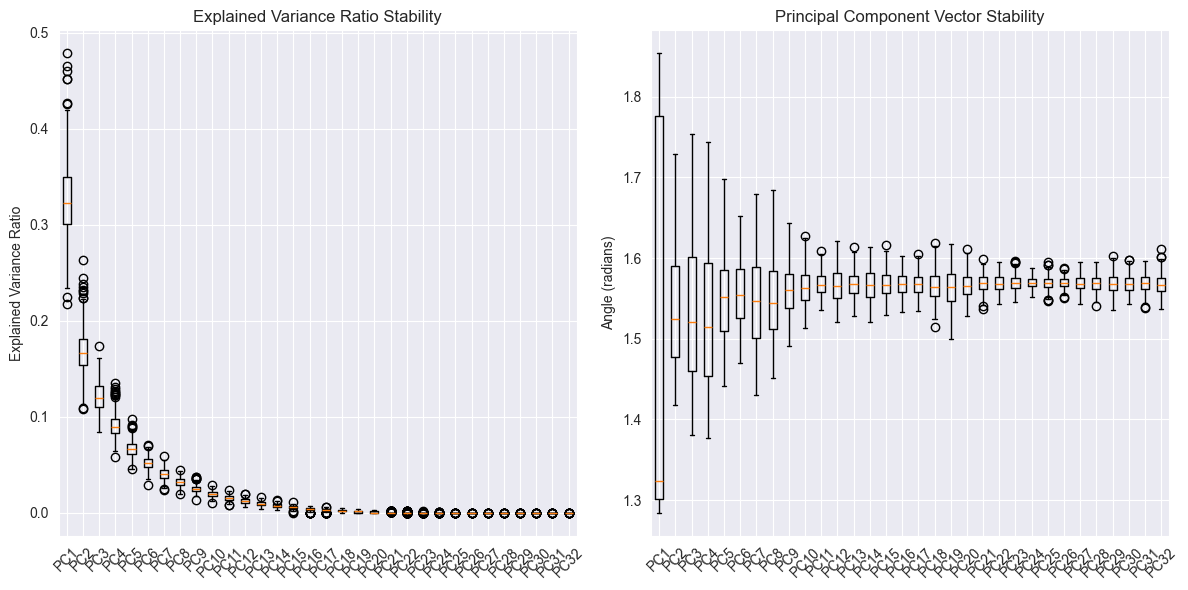

In [50]:
# cytof_init
n_components = 32
n_bootstrap = 500

transformed_features = get_imputed_features("cytof_init", "0of5")
explained_variance_ratio_, components_ = bootstrap_pca(transformed_features["train"], n_components, n_bootstrap)
plot_pca_stability(explained_variance_ratio_, components_, n_components)

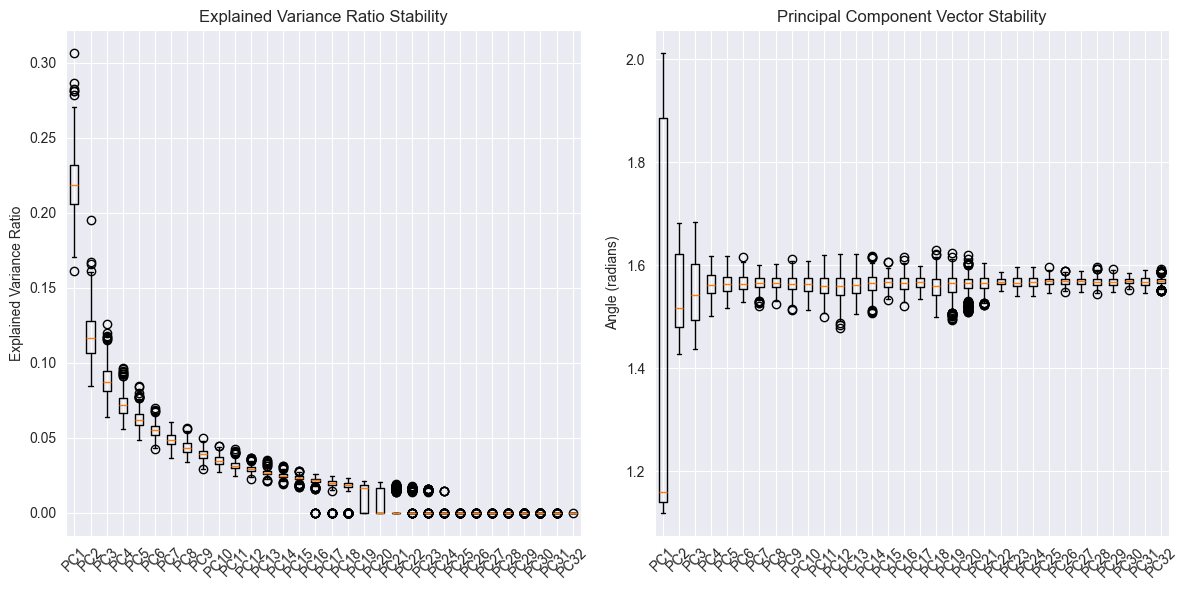

In [51]:
# transcriptomics
n_components = 32  # max number = number of samples
n_bootstrap = 500

transformed_features = get_imputed_features("transcriptomics", "0of5")
explained_variance_ratio_, components_ = bootstrap_pca(transformed_features["train"], n_components, n_bootstrap)
plot_pca_stability(explained_variance_ratio_, components_, n_components)

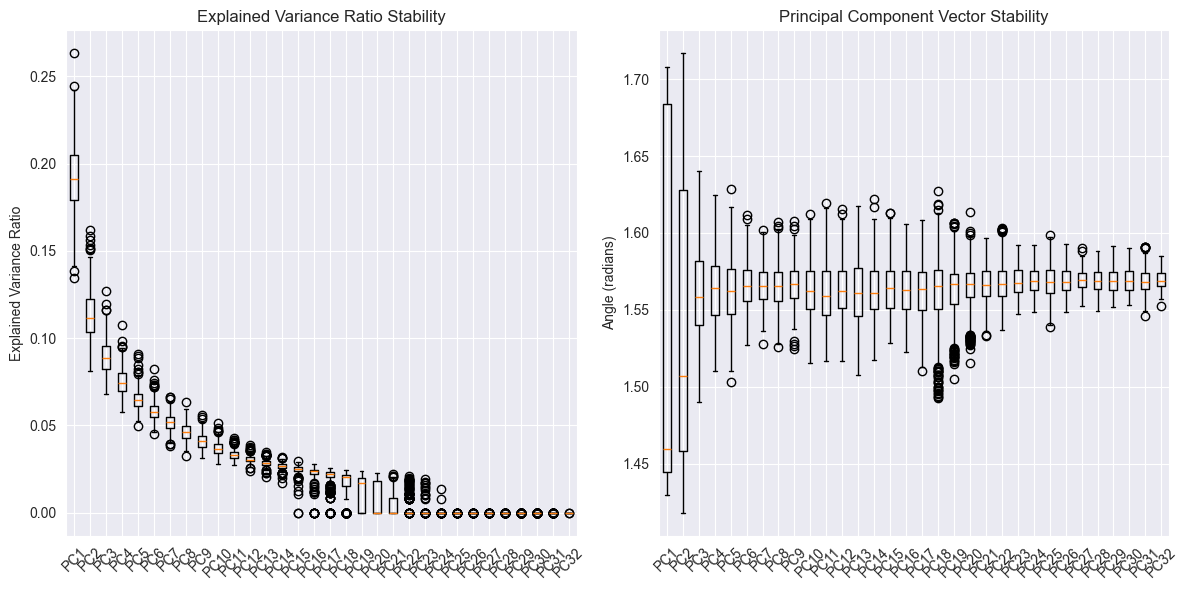

In [52]:
# proteomics
n_components = 32  # max number = number of samples
n_bootstrap = 500

transformed_features = get_imputed_features("proteomics", "0of5")
explained_variance_ratio_, components_ = bootstrap_pca(transformed_features["train"], n_components, n_bootstrap)
plot_pca_stability(explained_variance_ratio_, components_, n_components)